# Global Optimization (Particle Swarm)

In [1]:
from optiland import optic, optimization

Define a starting lens:

(<Figure size 1000x400 with 1 Axes>, <Axes: xlabel='Z [mm]', ylabel='Y [mm]'>)

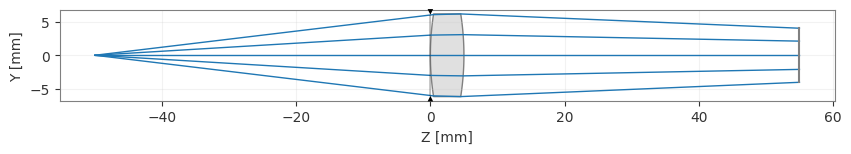

In [2]:
lens = optic.Optic()

# add surfaces
lens.surfaces.add(index=0, thickness=50)
lens.surfaces.add(index=1, thickness=5, radius=40, material="N-BK7", is_stop=True)
lens.surfaces.add(index=2, thickness=50, radius=-40)
lens.surfaces.add(index=3)

# set aperture
lens.set_aperture(aperture_type="EPD", value=12)

# add field
lens.fields.set_type(field_type="object_height")
lens.fields.add(y=0)

# add wavelength
lens.wavelengths.add(value=0.55, is_primary=True)

# draw lens
lens.draw(num_rays=5)

Define optimization problem:

In [3]:
problem = optimization.OptimizationProblem()

Add operands (targets for optimization):

In [4]:
# RMS spot size target
for field in lens.fields.get_field_coords():
    input_data = {
        "optic": lens,
        "Hx": field[0],
        "Hy": field[1],
        "surface_number": -1,
        "num_rays": 5,
        "wavelength": 0.55,
        "distribution": "hexapolar",
    }
    problem.add_operand(
        operand_type="rms_spot_size",
        target=0,
        weight=1,
        input_data=input_data,
    )

Define variables - we let the radii vary. Note that PSO requires finite bounds for all variables:

In [5]:
problem.add_variable(lens, "radius", surface_number=1, min_val=25, max_val=100)
problem.add_variable(lens, "radius", surface_number=2, min_val=-100, max_val=-25)

Check initial merit function value and system properties:

In [6]:
problem.info()

╒════╤════════════════════════╤═══════════════════╕
│    │   Merit Function Value │   Improvement (%) │
╞════╪════════════════════════╪═══════════════════╡
│  0 │                9.89095 │                 0 │
╘════╧════════════════════════╧═══════════════════╛
╒════╤════════════════╤══════════╤══════════════╤══════════════╤══════════╤═══════════════╤═════════╤═════════╤════════════════╕
│    │ Operand Type   │   Target │ Min. Bound   │ Max. Bound   │   Weight │   Eff. Weight │   Value │   Delta │   Contrib. [%] │
╞════╪════════════════╪══════════╪══════════════╪══════════════╪══════════╪═══════════════╪═════════╪═════════╪════════════════╡
│  0 │ rms spot size  │        0 │              │              │        1 │             1 │   3.145 │   3.145 │            100 │
╘════╧════════════════╧══════════╧══════════════╧══════════════╧══════════╧═══════════════╧═════════╧═════════╧════════════════╛
╒════╤═════════════════╤═══════════╤═════════╤══════════════╤══════════════╕
│    │ Variable Ty

Define optimizer:

In [7]:
optimizer = optimization.ParticleSwarm(problem)

Run optimization:

In [8]:
optimizer.optimize(maxiter=30, swarm_size=20, seed=42)

PSO start: best merit = 0.495756518209, swarm_size = 20, ndim = 2
Iter    1 | best merit = 0.385379232348 | improvement = 0.110377
Iter    2 | best merit = 0.0342386453248 | improvement = 0.351141
Iter    3 | best merit = 0.025628852796 | improvement = 0.00860979
Iter    4 | best merit = 0.025628852796 | improvement = 0
Iter    5 | best merit = 0.0238220692892 | improvement = 0.00180678
Iter    6 | best merit = 0.0238220692892 | improvement = 0
Iter    7 | best merit = 0.0232647160272 | improvement = 0.000557353
Iter    8 | best merit = 0.0232647160272 | improvement = 0
Iter    9 | best merit = 0.0232647160272 | improvement = 0
Iter   10 | best merit = 0.0232647160272 | improvement = 0
Iter   11 | best merit = 0.0232647160272 | improvement = 0
Iter   12 | best merit = 0.0232647160272 | improvement = 0
Iter   13 | best merit = 0.0232647160272 | improvement = 0
Iter   14 | best merit = 0.0229899364483 | improvement = 0.00027478
Iter   15 | best merit = 0.0229899364483 | improvement = 0
I

    message: Optimization converged: global best stalled within tol=0.001 for 20 iterations.
    success: True
        fun: 0.02294728407671323
          x: [-7.306e-01 -1.275e+00]
        nit: 25
       nfev: 520
 swarm_size: 20
    inertia: 0.7
 individual: 1.5
     social: 1.5

Print merit function value and system properties after optimization:

In [9]:
problem.info()

╒════╤════════════════════════╤═══════════════════╕
│    │   Merit Function Value │   Improvement (%) │
╞════╪════════════════════════╪═══════════════════╡
│  0 │              0.0229473 │            99.768 │
╘════╧════════════════════════╧═══════════════════╛
╒════╤════════════════╤══════════╤══════════════╤══════════════╤══════════╤═══════════════╤═════════╤═════════╤════════════════╕
│    │ Operand Type   │   Target │ Min. Bound   │ Max. Bound   │   Weight │   Eff. Weight │   Value │   Delta │   Contrib. [%] │
╞════╪════════════════╪══════════╪══════════════╪══════════════╪══════════╪═══════════════╪═════════╪═════════╪════════════════╡
│  0 │ rms spot size  │        0 │              │              │        1 │             1 │   0.151 │   0.151 │            100 │
╘════╧════════════════╧══════════╧══════════════╧══════════════╧══════════╧═══════════════╧═════════╧═════════╧════════════════╛
╒════╤═════════════════╤═══════════╤══════════╤══════════════╤══════════════╕
│    │ Variable T

Draw final lens:

(<Figure size 1000x400 with 1 Axes>, <Axes: xlabel='Z [mm]', ylabel='Y [mm]'>)

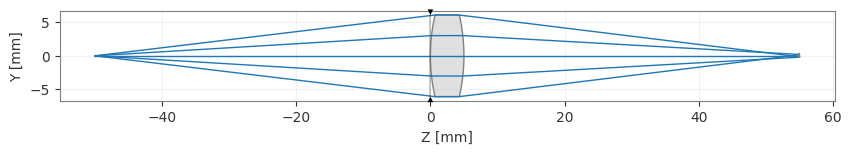

In [10]:
lens.draw(num_rays=5)